### **Modelagem Numérica do Acoplamento Hidromecânico em Reservatórios**

**Aluno:** Alexandre Altamir Moreira

Mestrado em Modelagem Computacional - LNCC (2026)

Este notebook tem por objetivo facilitar a implementação e explicações referentes ao trabalho final da disciplina GA-020. O foco é desenvolver e implementar um modelo numérico computacional para simular a interação hidromecânica em reservatórios. O estudo visa quantificar a difusão transiente da pressão do fluido no meio poroso ao longo do tempo e, a partir desse campo de pressões, utilizar o acoplamento de Biot como força interna motriz para determinar a resposta elástica e a consequente deformação estrutural da rocha.

### **Hipóteses do Modelo**

Neste trabalho, considera-se um problema de poroelasticidade baseado na teoria linear de Biot, adotando-se um acoplamento unidirecional (one-way coupling), no qual o campo de pressão influencia a resposta mecânica do meio, mas as deformações do esqueleto sólido não afetam a evolução do escoamento. Para a formulação do problema, são assumidas as seguintes hipóteses:

- O meio poroso encontra-se completamente saturado por uma única fase fluida, homogênea e contínua.
- As deformações do esqueleto sólido são suficientemente pequenas ($\|\nabla \mathbf{u}\| \ll 1$) para justificar a teoria da elasticidade linear e a linearização das equações governantes.
- As variações das grandezas físicas em torno do estado de referência são pequenas, permitindo a adoção de um regime de pequenas perturbações.
- O comportamento mecânico ocorre em regime quasi-estático, de modo que os efeitos inerciais são desprezados em comparação com as forças de equilíbrio.
- O escoamento do fluido através do meio poroso é governado pela Lei de Darcy, assumindo fluxo laminar e permeabilidade constante.
- O esqueleto sólido apresenta comportamento poroelástico linear isotrópico, caracterizado por propriedades mecânicas independentes da direção considerada.
- Efeitos térmicos, químicos, capilares e processos inelásticos, tais como plasticidade, dano ou fraturamento, são desconsiderados.
- O coeficiente de Biot é assumido igual à unidade ($\alpha = 1$), implicando que as variações de pressão nos poros são integralmente transmitidas ao esqueleto sólido. Essa hipótese é frequentemente adotada para materiais altamente porosos e permite simplificar a formulação do problema.

Sob essas hipóteses, busca-se desenvolver a formulação deslocamento-pressão (u-p) da poroelasticidade linear, na qual os campos de deslocamento do sólido e pressão de poros constituem as variáveis primárias do problema.

### **Modelo matemático e formulação Variacional do problema**

Considere o sistema acoplado (uma via) governado pelas seguintes equações diferenciais parciais:

$$
\begin{cases}
\beta\dfrac{\partial P}{\partial t} - \nabla\cdot\left(\dfrac{k}{\mu_f}\nabla P\right)=0, \\[10pt]
\nabla\cdot\sigma(\mathbf{u}) - \nabla P = \mathbf{0},
\end{cases}
$$

onde o tensor de tensões para elasticidade linear isotrópica é dado por

$$
\sigma(\mathbf{u}) = 2\mu\,\varepsilon(\mathbf{u}) + \lambda\,\operatorname{tr}(\varepsilon(\mathbf{u}))\,\mathbf{I} + \sigma_{0},
$$

e o tensor de pequenas deformações é

$$
\varepsilon(\mathbf{u}) = \frac{1}{2} \left( \nabla\mathbf{u} + \nabla\mathbf{u}^{T} \right).
$$

## **O Problema Discreto**

Aplicando o método de Euler implícito para a discretização temporal da equação da difusão de pressão, a formulação variacional (forma fraca) consiste em:

**1. Problema Hidráulico:**
Encontrar a pressão atual $P^{n+1}\in V$ tal que, para toda função teste escalar $q\in V$,

$$
\beta \int_{\Omega} P^{n+1}q\,d\Omega + \Delta t \int_{\Omega} \frac{k}{\mu_f} \nabla P^{n+1}\cdot\nabla q\,d\Omega = \beta \int_{\Omega} P^n q\,d\Omega.
$$

**2. Problema Mecânico:**
Multiplicando a equação de equilíbrio por uma função teste vetorial $\mathbf{v}$ e integrando por partes apenas o termo da tensão (desprezando os termos naturais de contorno), a formulação variacional consiste em encontrar o deslocamento $\mathbf{u}\in W$ tal que, para toda função teste vetorial $\mathbf{v}\in W$,

$$
\int_{\Omega} \boldsymbol{\sigma}'(\mathbf{u}) : \varepsilon(\mathbf{v}) \, d\Omega = \int_{\Omega} P (\nabla \cdot \mathbf{v}) \, d\Omega + \int_{\Gamma_N} \mathbf{t} \cdot \mathbf{v} \, d\Gamma
$$

### **Importação das dependências necessárias**


In [82]:
# fmt: off
# isort: off

import os

os.environ.setdefault("OMP_NUM_THREADS", "1")
os.environ.setdefault("OPENBLAS_NUM_THREADS", "1")
os.environ.setdefault("VECLIB_MAXIMUM_THREADS", "1")

import matplotlib.pyplot as plt
import numpy as np
from firedrake import *
from firedrake import PointEvaluator

# isort: on
# fmt: on

### **Definição da geometria da malha e dos espaços de funções**

In [83]:
Lx = 200.0  # metros
Ly = 200.0  # metros
domain = RectangleMesh(40, 40, Lx, Ly)

V = VectorFunctionSpace(domain, "CG", 2)  # Deslocamento do Sólido (Vetor)
Q = FunctionSpace(domain, "CG", 1)  # Pressão do Fluido (Escalar)

# Funções teste
u = TrialFunction(V)
v = TestFunction(V)
P = TrialFunction(Q)
q = TestFunction(Q)

### **Definição dos parâmetros físicos do esqueleto poroso e do fluido**

**Relação entre $E$, $\nu$ e as Constantes de Lamé**

As constantes de Lamé podem ser escritas em função do módulo de Young $E$ e do coeficiente de Poisson $\nu$:

$$\mu = \frac{E}{2(1 + \nu)}, \quad \lambda = \frac{E\nu}{(1 + \nu)(1 - 2\nu)}$$

* **Módulo de Young ($E$):** Mede a rigidez axial do material (relação entre tensão e deformação linear na mesma direção).
  
  $$E = \frac{\sigma}{\epsilon_{\text{axial}}}$$

* **Coeficiente de Poisson ($\nu$):** Mede o acoplamento entre as deformações axial e lateral (o quanto o material "estufa" para os lados ao ser esmagado).
  
  $$\nu = -\frac{\epsilon_{\text{transversal}}}{\epsilon_{\text{axial}}}$$

In [84]:
# Sólido:
E = 10.0e9
nu = 0.25
mu_value = E / (2.0 * (1.0 + nu))
lambda_value = E * nu / ((1.0 + nu) * (1.0 - 2.0 * nu))
mu = Constant(mu_value)
lambda_ = Constant(lambda_value)
I = Identity(domain.geometric_dimension)

# Tensão In-Situ (Estado de tensão inicial da rocha a milhares de metros)
sigma_h0 = -50.0e6  # Compressão horizontal (50 MPa)
sigma_v0 = -70.0e6  # Compressão vertical (70 MPa)

sigma_0 = as_tensor([[Constant(sigma_h0), 0.0], [0.0, Constant(sigma_v0)]])

# Dados do problema hidráulico
P0 = 1.5e7
P_inj_val = 2.5e7  # 250 bar (Injeção na Esquerda)
P_prod_val = 1.5e7  # 150 bar (Produção na Direita)

# Propriedades Poroelásticas (Beta -> One-Way)
porosidade = Constant(0.20)  # Porosidade do arenito (20%)
c_f = Constant(4.0e-10)  # Compressibilidade da água (Pa^-1)
c_m = Constant(1.0e-9)  # Compressibilidade da matriz da rocha (Pa^-1)
beta = Constant(porosidade * c_f + c_m)  # Coef. de Armazenamento Específico

# Fluido e Permeabilidade
k_perm_val = 1.0e-15  # Permeabilidade do Arenito (m²)
mu_f_val = 1.0e-3  # Viscosidade da Água (Pa.s)
inv_K = Constant(mu_f_val / k_perm_val)  # Resistividade Hidráulica (1/K)

# Discretização temporal
total_time = 100.0 * 24.0 * 3600
num_steps = 150
dt_value = total_time / num_steps
dt = Constant(dt_value)  # Passo de tempo

### **Fundamentação Teórica da Elasticidade Linear Isotrópica**

O comportamento mecânico do esqueleto sólido em um meio poroso baseia-se na mecânica dos meios contínuos para pequenas deformações, onde o estado de deformação e o estado de tensão em qualquer ponto do domínio são descritos por tensores de segunda ordem.

#### 1. Cinemática: O Tensor de Pequenas Deformações ($\epsilon$)
A partir do vetor de deslocamento $\mathbf{u} = (u_x, u_y)^T$, que mapeia a mudança de posição de cada partícula do sólido no espaço bidimensional, define-se o gradiente de deslocamentos $\nabla \mathbf{u}$. Para o cenário de pequenas deformações (elasticidade linear), desprezam-se os termos não-lineares de ordem superior, resultando no **Tensor de Deformações Infinitesimais de Cauchy**:

$$\epsilon = \frac{1}{2} \left( \nabla \mathbf{u} + (\nabla \mathbf{u})^T \right) = \operatorname{sym}(\nabla \mathbf{u})$$

Em termos de componentes no plano $xy$, o tensor assume a forma simétrica:

$$\epsilon = \begin{bmatrix} \epsilon_{xx} & \epsilon_{xy} \\ \epsilon_{yx} & \epsilon_{yy} \end{bmatrix} = \begin{bmatrix} \frac{\partial u_x}{\partial x} & \frac{1}{2}\left(\frac{\partial u_x}{\partial y} + \frac{\partial u_y}{\partial x}\right) \\ \frac{1}{2}\left(\frac{\partial u_x}{\partial y} + \frac{\partial u_y}{\partial x}\right) & \frac{\partial u_y}{\partial y} \end{bmatrix}$$

A extração da parte simétrica do operador gradiente ($\operatorname{sym}$) é uma exigência cinemática fundamental. Ela garante que movimentos de rotação pura de corpo rígido (que não alteram as distâncias internas entre as partículas e, portanto, não geram forças internas) resultem em um tensor nulo ($\epsilon = 0$).

#### 2. Equação Constitutiva: Tensor de Tensões de Cauchy ($\sigma$) e as Constantes de Lamé
A resposta dinâmica do esqueleto sólido ao ser deformado é governada pela **Lei de Hooke Generalizada**. Para um meio puramente isotrópico (cujas propriedades mecânicas não variam com a direção espacial), a relação constitutiva mais elegante que vincula o tensor de tensões ($\sigma$) ao tensor de deformações ($\epsilon$) é expressa em termos das **Constantes de Lamé** ($\lambda$ e $\mu$):

$$\sigma = \lambda \operatorname{tr}(\epsilon) \mathbf{I} + 2\mu \epsilon$$

Onde:
* $\mathbf{I}$ é o tensor identidade de segunda ordem ($\mathbf{I} = \delta_{ij}$).
* $\operatorname{tr}(\epsilon)$ é o traço do tensor de deformações ($\epsilon_{xx} + \epsilon_{yy}$), operador invariante que quantifica matematicamente a **dilatação volumétrica local** ($\epsilon_v = \Delta V / V_0$).

Esta formulação decompõe fisicamente a resposta de tensão em dois mecanismos independentes:
1. **Comportamento Volumétrico ($\lambda \operatorname{tr}(\epsilon) \mathbf{I}$):** Modifica a magnitude das tensões normais hidrostáticas uniformemente quando ocorre variação no volume do elemento infinitesimal.
2. **Comportamento Desviatório ou Distorcional ($2\mu \epsilon$):** Atua diretamente nas deformações cisalhantes e diferenciais, quantificando a resistência do esqueleto sólido à mudança de forma sem alteração de volume.

In [85]:
# Tensores de deformação e tensão
def epsilon(w):
    return sym(grad(w))


def sigma(w):
    return lambda_ * tr(epsilon(w)) * I + 2.0 * mu * epsilon(w)

### Condições Iniciais, de Contorno e Partição da Fronteira

Para garantir que o sistema de equações diferenciais parciais acopladas de Biot seja um problema matematicamente bem-posto, é necessário definir o domínio físico ($\Omega$), o intervalo de tempo ($t \in (0, T]$) e um conjunto consistente de condições iniciais e de contorno. 

A fronteira total do domínio ($\partial\Omega$) é dividida em partições disjuntas para os campos mecânico e hidráulico:

#### 1. Fronteira Mecânica ($\partial\Omega = \Gamma_u \cup \Gamma_t$)
O modelo adota uma configuração de **confinamento odométrico**, que simula de forma realista o comportamento de um reservatório confinado pela rocha adjacente:

* **Deslocamento Prescrito ($\Gamma_u$):**
  * **Face Inferior (Base):** Configurada com uma condição de Dirichlet homogênea total ($\mathbf{u} = (0.0, 0.0)^T$). Fisicamente, representa o engastamento do reservatório no embasamento rochoso rígido.
  * **Faces Laterais (Esquerda e Direita):** Configuradas com restrição horizontal de roletes, impondo $u_x = 0$, enquanto a componente vertical $u_y$ permanece livre. Isto impede o deslocamento lateral do reservatório (assumindo extensão infinita ou confinamento geomecânico rígido nas laterais), mas permite a sua livre compactação ou expansão vertical.

* **Tração Prescrita ($\Gamma_t$ - Condição de Neumann):**
  * **Face Superior (Topo):** Sujeita a uma tensão vertical prescrita não-homogênea ($\boldsymbol{\sigma}_{total} \cdot \mathbf{n} = \bar{\mathbf{t}}$), onde $\bar{\mathbf{t}} = (0, -25 \text{ MPa})^T$. Esta força representa o peso da coluna de rocha sobrejacente, que comprime continuamente o topo do reservatório.

#### 2. Fronteira Hidráulica ($\partial\Omega = \Gamma_p \cup \Gamma_v$)
* **Pressão Prescrita ($\Gamma_p$):** O modelo simula um gradiente de pressão transiente clássico:
  * **Injeção (Esquerda):** Mantida com pressão elevada (sobrepressão), simulando a introdução de fluido através de um poço injetor ou uma zona sobrepressurizada.
  * **Produção (Direita):** Mantida sob pressão reduzida de operação, atuando como uma fronteira drenante (sumidouro) que permite a dissipação e troca de fluido com o exterior.

* **Fluxo Normal Prescrito ($\Gamma_v$):** Região onde a velocidade de filtragem de Darcy na direção normal é nula. As fronteiras superior e inferior operam sob a condição de paredes impermeáveis:
  $$\mathbf{v} \cdot \mathbf{n} = 0 \quad \text{em} \quad \Gamma_v \text{ (Superior e Inferior)}$$
  Isto força o fluxo de fluido a deslocar-se estritamente de forma horizontal, da esquerda para a direita.

#### 3. Condições Iniciais ($t = 0$)
Como o acoplamento implementado é do tipo *One-Way* com uma mecânica quasi-estática (equilíbrio mecânico instantâneo a cada instante), a variável que dita a evolução temporal difusiva é a pressão de poro. Define-se o estado hidráulico inicial uniforme em todo o domínio como o estado de equilíbrio hidrostático original do reservatório:
$$p(\mathbf{x}, 0) = 150 \quad \text{bar} \quad \forall \mathbf{x} \in \Omega$$

#### Interdependência Física das Fronteiras
Nesta nova configuração, a interdependência poromecânica torna-se ainda mais evidente. Como as laterais estão travadas em $x$, qualquer tentativa de expansão volumétrica ($\nabla \cdot \mathbf{u}$) decorrente da injeção de fluido na esquerda resultará num aumento severo das tensões efetivas horizontais contra as paredes do modelo. Da mesma forma, a sobrecarga de $25\text{ MPa}$ no topo força com que a dissipação da pressão de poro em direção à face drenante direita dite diretamente a taxa de compactação vertical (adensamento) do meio poroso ao longo do tempo.

In [86]:
# Condições iniciais e de contorno

# Condição Inicial (na célula de dados)
P_n = Function(Q, name="pressao_inicial").assign(P0)
P_initial = Function(Q, name="pressao_plot_inicial").assign(P_n)

# Rampa de injeção: Começa em P0 para não dar choque numérico
P_inj_atual = Constant(P0)

# Condições de Contorno Hidráulicas
bc_P_esq = DirichletBC(Q, P_inj_atual, 1)  # Variável no tempo
bc_P_dir = DirichletBC(Q, P_prod_val, 2)  # Fixa
bcs_fluido = [bc_P_esq, bc_P_dir]

# Condições de Contorno Mecânicas (Odométricas) - Murad
bc_u_base = DirichletBC(V, Constant((0.0, 0.0)), 3)  # Base travada
bc_u_esq = DirichletBC(V.sub(0), Constant(0.0), 1)  # Lateral esquerda: ux = 0
bc_u_dir = DirichletBC(V.sub(0), Constant(0.0), 2)  # Lateral direita: ux = 0
bcs_solido = [bc_u_base, bc_u_esq, bc_u_dir]

# Vetor de Tração Externa (Neumann no Topo - Face 4) - Ir mudando e observando efeitos
# Carga de equilíbrio inicial calculada (-70 MPa in-situ - 15 MPa poro = -85 MPa)
carga_equilibrio = -85.0e6
T_sobrecarga = Constant((0.0, carga_equilibrio))

# Funções para armazenar os campos atuais - SOLUÇÕES
P_h = Function(Q, name="pressao_atual")
u_h = Function(V, name="deslocamento_atual")

In [87]:
# Forma fraca das edp's

# Lado esquerdo e direito do fluido (Euler Implícito)
a_fluido = (beta * P * q + dt * (1.0 / inv_K) * inner(grad(P), grad(q))) * dx
L_fluido = beta * P_n * q * dx


# Forma fraca do sólido corrigida (MURAD)
a_solido = inner(sigma(u), epsilon(v)) * dx
L_solido = (
    P_h * div(v) * dx + dot(T_sobrecarga, v) * ds(4) - inner(sigma_0, epsilon(v)) * dx
)

### Loop temporal

In [88]:
# Armazenar QOIs
times = np.linspace(0.0, total_time, num_steps + 1)  # discretização do domínio temporal
times_days = times / (24.0 * 3600.0)
mean_pressures = np.zeros(num_steps + 1)
max_displacements = np.zeros(num_steps + 1)
strain_energies = np.zeros(num_steps + 1)
domain_area = float(assemble(Constant(1.0) * dx(domain)))


# Estado inicial (t = 0)
mean_pressures[0] = float(assemble(P_n * dx) / domain_area)
u_mag_temp = Function(Q).interpolate(sqrt(dot(u_h, u_h)))
max_displacements[0] = u_mag_temp.dat.data_ro.max()
strain_energies[0] = float(assemble(0.5 * inner(sigma(u_h), epsilon(u_h)) * dx))


# Para plotagem dos campos em instantes arbitrários - Sugestão Volpatto
steps_to_plot = [
    int(num_steps * 0.05),
    int(num_steps * 0.25),
    int(num_steps * 0.60),
    num_steps,
]

P_instantes, u_instantes, t_instantes = [], [], []


for step in range(1, num_steps + 1):

    tempo_atual_dias = times_days[step]

    # Atualiza a rampa de injeção (atinge pressão máxima em 5 dias)
    fator_rampa = min(tempo_atual_dias / 5.0, 1.0)
    P_inj_atual.assign(P0 + (P_inj_val - P0) * fator_rampa)

    # Resolver problema hidráulico
    solve(
        a_fluido == L_fluido,
        P_h,
        bcs=bcs_fluido,
        solver_parameters={"ksp_type": "preonly", "pc_type": "lu"},
    )

    # Resolver problema mecânico - condições odométricas
    solve(
        a_solido == L_solido,
        u_h,
        bcs=bcs_solido,
        solver_parameters={"ksp_type": "preonly", "pc_type": "lu"},
    )

    # Armazenar a Pressão Média (Pa)
    mean_pressures[step] = float(assemble(P_h * dx) / domain_area)

    # Deslocamento máximo
    u_mag_temp = Function(Q).interpolate(sqrt(dot(u_h, u_h) + 1e-14))
    max_displacements[step] = u_mag_temp.dat.data_ro.max()

    # Energia Elástica - AULA MEF (Volpatto)
    strain_energies[step] = float(assemble(0.5 * inner(sigma(u_h), epsilon(u_h)) * dx))

    # Salvar campos nos instantes definidos
    if step in steps_to_plot:
        P_instantes.append(Function(Q).assign(P_h))
        u_instantes.append(Function(V).assign(u_h))
        t_instantes.append(times_days[step])

    P_n.assign(P_h)

print("Simulação temporal concluída!\n")

Simulação temporal concluída!



### Quantidades de interesse do problema - Recuperadas a partir das soluções obtidas
| 1. Evolução Temporal | 2. Campos Espaciais (2D) | 3. Quantidades Derivadas |
| :--- | :--- | :--- |
| • Pressão média do reservatório <br> • Deslocamento máximo da rocha <br> • Energia elástica de deformação | • Campo de pressão Inicial <br> • Campo de pressão Final <br> • Magnitude e cinemática do deslocamento <br> • Campo de tensão de Von Mises | • Limites do deslocamento horizontal ($u_{x}$) <br> • Limites do deslocamento vertical ($u_{y}$) <br> • Pico da magnitude do deslocamento ($\|u\|$) <br> • Energia elástica total |

In [89]:
# Quantidades derivadas

print("Quantidades de interesse de engenharia\n")
print("-----------------------------------------")
u_x = Function(Q, name="u_x").interpolate(u_h[0])
u_y = Function(Q, name="u_y").interpolate(u_h[1])
u_mag = Function(Q, name="u_mag").interpolate(sqrt(dot(u_h, u_h) + 1e-14))
strain_energy = 0.5 * assemble(inner(sigma(u_h), epsilon(u_h)) * dx)

print(f"u_x em [{u_x.dat.data_ro.min():.6e}, {u_x.dat.data_ro.max():.6e}] m")
print(f"u_y em [{u_y.dat.data_ro.min():.6e}, {u_y.dat.data_ro.max():.6e}] m")
print(f"|u| máximo: {u_mag.dat.data_ro.max():.6e} m")
print(f"Energia elástica total: {float(strain_energy):.6e} J")
print("-----------------------------------------\n")

Quantidades de interesse de engenharia

-----------------------------------------
u_x em [0.000000e+00, 3.232460e-02] m
u_y em [0.000000e+00, 1.110753e-01] m
|u| máximo: 1.110753e-01 m
Energia elástica total: 4.933008e+07 J
-----------------------------------------



### Evolução temporal

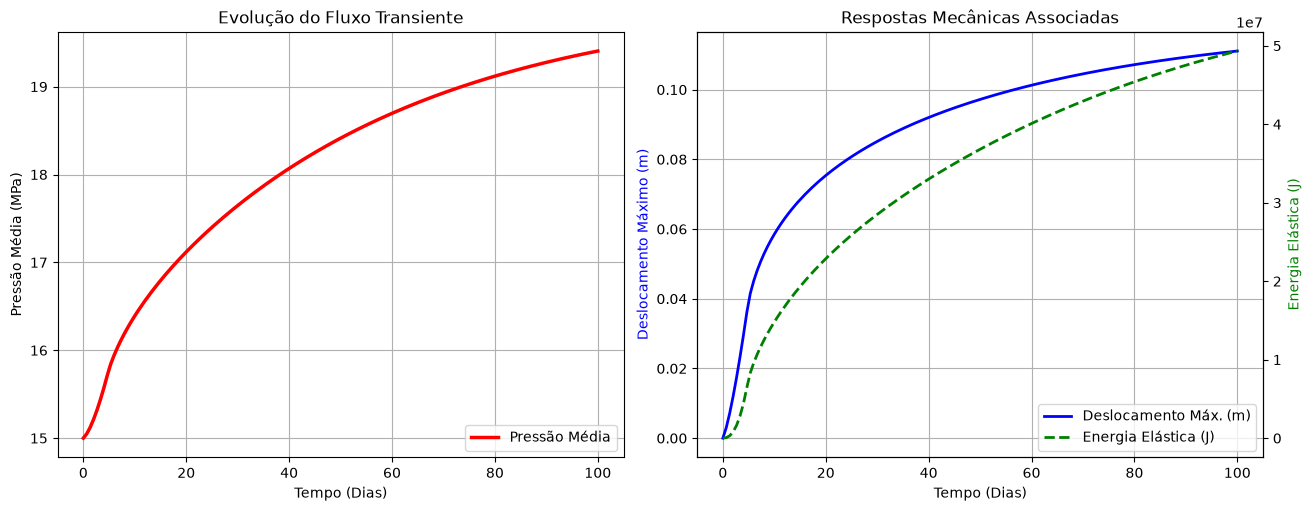

In [90]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5), constrained_layout=True)

ax1.plot(times_days, mean_pressures / 1e6, "r-", linewidth=2.5, label="Pressão Média")
ax1.set_xlabel("Tempo (Dias)")
ax1.set_ylabel("Pressão Média (MPa)")
ax1.grid(True)
ax1.legend(loc="lower right")
ax1.set_title("Evolução do Fluxo Transiente")

ax2_disp = ax2
ax2_energy = ax2.twinx()

line1 = ax2_disp.plot(
    times_days, max_displacements, "b-", linewidth=2, label="Deslocamento Máx. (m)"
)
line2 = ax2_energy.plot(
    times_days, strain_energies, "g--", linewidth=2, label="Energia Elástica (J)"
)

ax2_disp.set_xlabel("Tempo (Dias)")
ax2_disp.set_ylabel("Deslocamento Máximo (m)", color="b")
ax2_energy.set_ylabel("Energia Elástica (J)", color="g")

lines = line1 + line2
labels = [l.get_label() for l in lines]
ax2_disp.legend(lines, labels, loc="lower right")
ax2_disp.grid(True)
ax2_disp.set_title("Respostas Mecânicas Associadas")

# plt.savefig("historico_temporal.png", dpi=300)
plt.show()

### **Evolução espacial do campo de pressões e de deslocamentos**

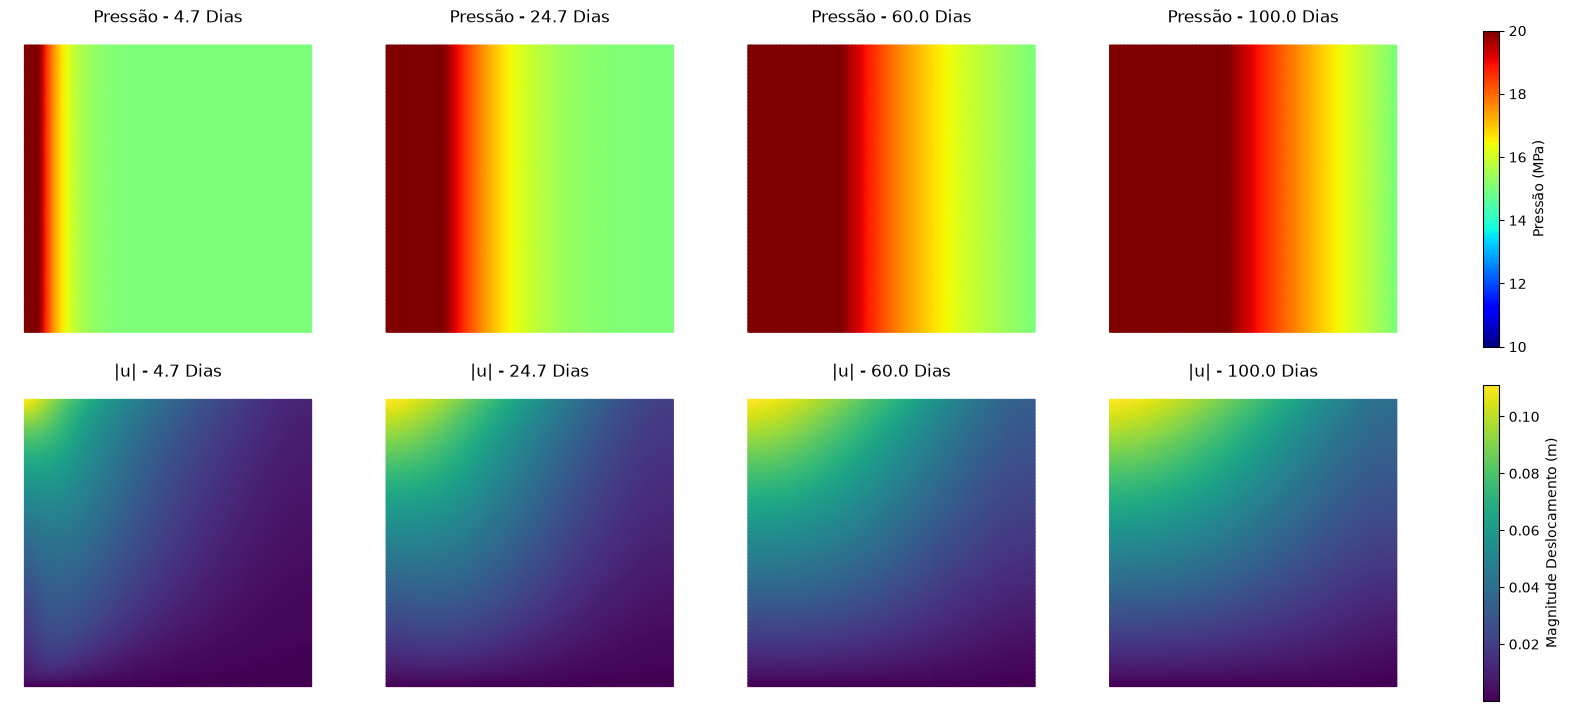

In [91]:
num_instantes = len(t_instantes)
fig_spatial, axes = plt.subplots(
    2, num_instantes, figsize=(16, 7), constrained_layout=True
)

for i in range(num_instantes):
    # Linha 1: Evolução da Pressão
    P_MPa = Function(Q).assign(P_instantes[i] / 1e6)
    c1 = tripcolor(P_MPa, axes=axes[0, i], cmap="jet", vmin=10.0, vmax=20.0)
    axes[0, i].set_title(f"Pressão - {t_instantes[i]:.1f} Dias")
    axes[0, i].set_aspect("equal")
    axes[0, i].axis("off")

    # Linha 2: Evolução do Deslocamento
    u_mag = Function(Q).interpolate(sqrt(dot(u_instantes[i], u_instantes[i]) + 1e-14))
    c2 = tripcolor(u_mag, axes=axes[1, i], cmap="viridis")
    axes[1, i].set_title(f"|u| - {t_instantes[i]:.1f} Dias")
    axes[1, i].set_aspect("equal")
    axes[1, i].axis("off")

# Adicionar barras de cor para o painel
fig_spatial.colorbar(
    c1, ax=axes[0, :], label="Pressão (MPa)", location="right", aspect=20
)
fig_spatial.colorbar(
    c2, ax=axes[1, :], label="Magnitude Deslocamento (m)", location="right", aspect=20
)

plt.show()

De maneira análoga ao apresentado na aula sobre implementação de Elementos Finitos, plota-se o campo vetorial com quiver. Em seguida, exibe-se a magnitude e as duas componentes do deslocamento. 

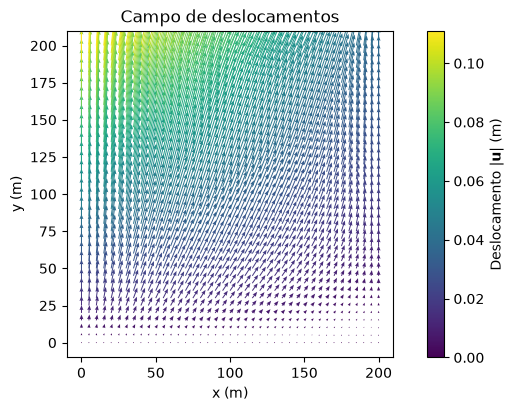

In [92]:
fig_q, ax_q = plt.subplots(figsize=(8, 4), constrained_layout=True)
collection_q = quiver(
    u_h,
    axes=ax_q,
    scale=0.5,
    width=0.003,
    headwidth=4,
    headlength=5,
)

fig_q.colorbar(collection_q, ax=ax_q, label=r"Deslocamento $|\mathbf{u}|$ (m)")
ax_q.set_aspect("equal")
ax_q.set_xlabel("x (m)")
ax_q.set_ylabel("y (m)")
ax_q.set_title("Campo de deslocamentos")

plt.show()

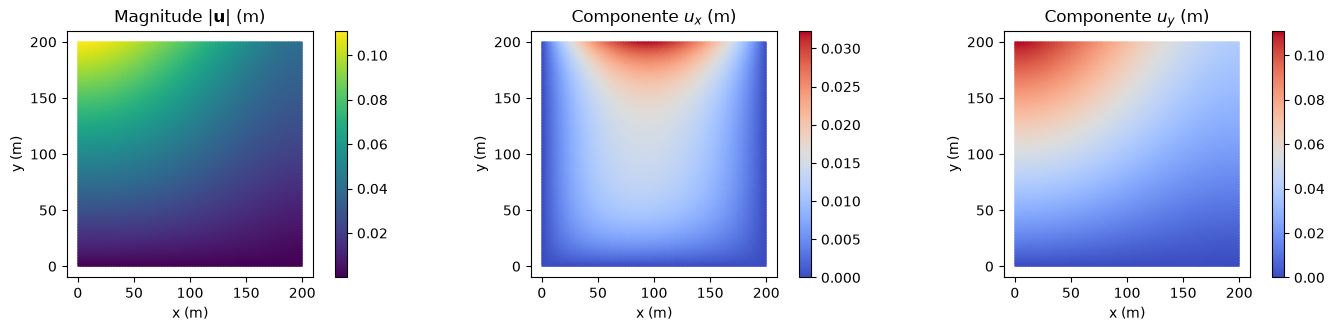

In [93]:
fig, axes = plt.subplots(1, 3, figsize=(14, 3.2), constrained_layout=True)

for ax, field, title, cmap in [
    (axes[0], u_mag, r"Magnitude $|\mathbf{u}|$ (m)", "viridis"),
    (axes[1], u_x, r"Componente $u_x$ (m)", "coolwarm"),
    (axes[2], u_y, r"Componente $u_y$ (m)", "coolwarm"),
]:
    collection = tripcolor(field, axes=ax, cmap=cmap)
    fig.colorbar(collection, ax=ax)
    ax.set_aspect("equal")
    ax.set_xlabel("x (m)")
    ax.set_ylabel("y (m)")
    ax.set_title(title)

plt.show()

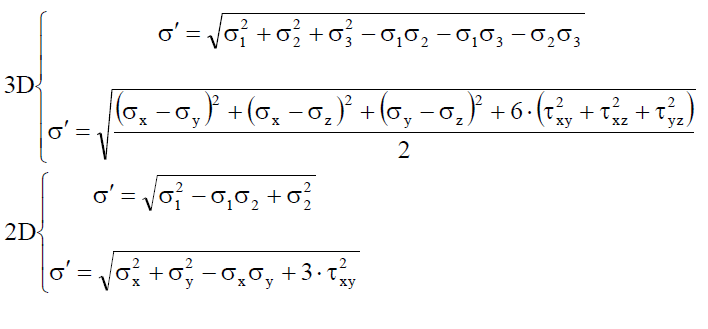

Para a análise do problema hidro-mecânico, foram selecionadas três variáveis de interesse que representam aspectos complementares do comportamento do meio poroso: a velocidade de Darcy, a deformação volumétrica e a tensão equivalente de von Mises. A velocidade de Darcy permite avaliar a distribuição espacial do fluxo de fluido no domínio, identificando regiões de maior ou menor escoamento e fornecendo informações sobre os mecanismos de transporte através do meio poroso. A deformação volumétrica, calculada pelo divergente do campo de deslocamentos, é utilizada para quantificar a variação local de volume do material, indicando zonas de compressão ou expansão associadas à interação entre pressões de poros e deformações da matriz sólida. Por fim, a tensão equivalente de von Mises é empregada como um indicador escalar do estado de tensões mecânicas, permitindo identificar regiões sujeitas a maiores concentrações de tensões e, consequentemente, mais suscetíveis a processos de deformação permanente ou falha do material.

Resultados - Darcy, Deformação Volumétrica e von Mises


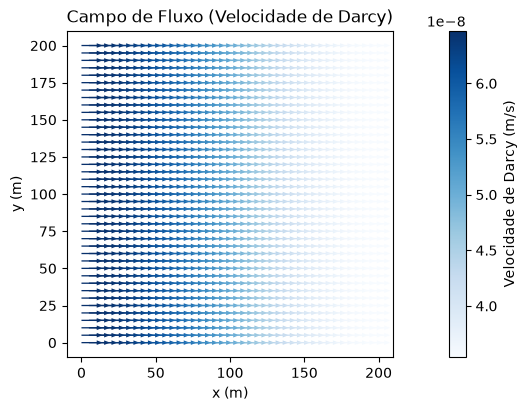

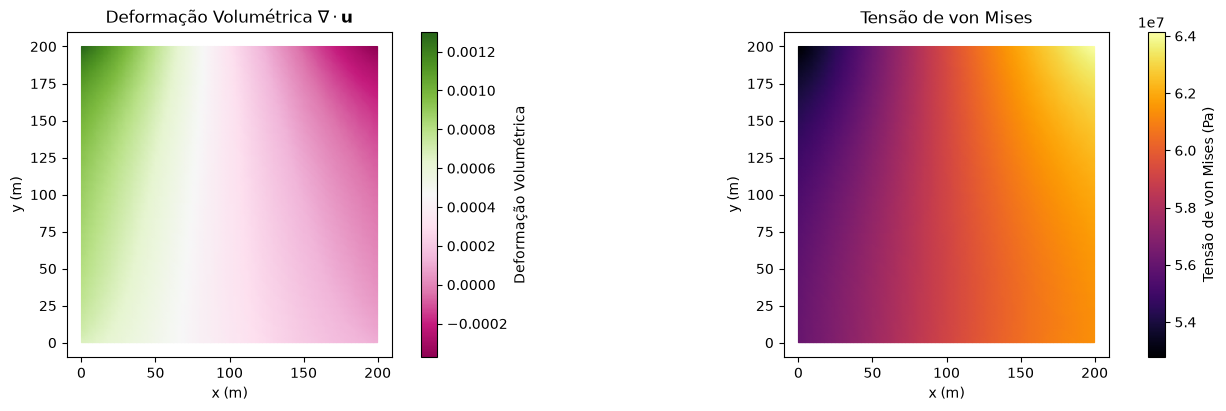

In [94]:
print("Resultados - Darcy, Deformação Volumétrica e von Mises")

# 1. Velocidade de Darcy - Calculada usando o gradiente da pressão no estado final (P_h)
W_darcy = VectorFunctionSpace(domain, "DG", 0)

# 1. Velocidade de Darcy - Calculada corretamente no espaço DG0 usando inv_K
v_darcy = project(-(1.0 / inv_K) * grad(P_h), W_darcy)

# 2. Deformação Volumétrica (Escalar)
eps_vol = project(div(u_h), Q)

# 3. Tensão de von Mises (Escalar) - Usando as componentes da matriz de tensão
sig_total = sigma(u_h) + sigma_0  # <-- Somamos aqui para ver a realidade geomecânica
von_Mises_expr = sqrt(
    sig_total[0, 0] ** 2
    + sig_total[1, 1] ** 2
    - sig_total[0, 0] * sig_total[1, 1]
    + 3 * sig_total[0, 1] ** 2
    + 1e-14
)
von_Mises = project(von_Mises_expr, Q)


# Campo de velocidades (Darcy)
fig_d, ax_d = plt.subplots(figsize=(8, 4), constrained_layout=True)
col_d = quiver(
    v_darcy,
    axes=ax_d,
    cmap="Blues",
    scale=1e-6,
    width=0.004,
    headwidth=3.5,
    headlength=4.5,
)
fig_d.colorbar(col_d, ax=ax_d, label="Velocidade de Darcy (m/s)")
ax_d.set_xlabel("x (m)")
ax_d.set_ylabel("y (m)")
ax_d.set_title("Campo de Fluxo (Velocidade de Darcy)")
ax_d.set_aspect("equal")
plt.show()

# Tensões - verde mostra expansão, rosa/roxo mostra compressão
fig_em, axes_em = plt.subplots(1, 2, figsize=(14, 4), constrained_layout=True)

c_vol = tripcolor(eps_vol, axes=axes_em[0], cmap="PiYG")
fig_em.colorbar(c_vol, ax=axes_em[0], label="Deformação Volumétrica")
axes_em[0].set_xlabel("x (m)")
axes_em[0].set_ylabel("y (m)")
axes_em[0].set_title(r"Deformação Volumétrica $\nabla \cdot \mathbf{u}$")
axes_em[0].set_aspect("equal")

# Tensão de von Mises
c_vm = tripcolor(von_Mises, axes=axes_em[1], cmap="inferno")
fig_em.colorbar(c_vm, ax=axes_em[1], label="Tensão de von Mises (Pa)")
axes_em[1].set_xlabel("x (m)")
axes_em[1].set_ylabel("y (m)")
axes_em[1].set_title("Tensão de von Mises")
axes_em[1].set_aspect("equal")

plt.show()

### **Sugestões - Murad/Volpatto**

### Perfil de Análise Linear: Resposta Hidromecânica ao Longo de $y = L_y/2$

Com o objetivo de investigar quantitativamente a resposta hidromecânica do sistema e reduzir as limitações interpretativas inerentes aos mapas de contorno bidimensionais, realiza-se a extração de um perfil linear (*line-out*) das variáveis primárias analisadas: a pressão de poros ($P$) e a magnitude do vetor deslocamento ($\|\mathbf{u}\|$).

A amostragem é efetuada ao longo da linha horizontal que atravessa o centro geométrico do domínio computacional, correspondente à coordenada $y = L_y/2$, para todo $x \in [0, L_x]$. Essa estratégia permite examinar, de forma direta e contínua, a evolução espacial das respostas hidráulica e mecânica ao longo da principal direção de escoamento.

O perfil obtido descreve a transição entre a região de injeção a montante ($x = 0$), caracterizada por maiores níveis de pressão, e a zona de produção ou drenagem a jusante ($x = L_x$), onde a pressão tende a diminuir em função das condições de contorno impostas. A análise simultânea de $P$ e $\|\mathbf{u}\|$ permite identificar a distribuição do gradiente hidráulico e sua influência sobre a deformação do meio poroso.

Como o problema é formulado sob um esquema de acoplamento unidirecional (*one-way coupling*), o campo de pressão atua como carregamento para o problema mecânico, enquanto as deformações do esqueleto sólido não alteram a solução hidráulica. Dessa forma, os perfis extraídos permitem avaliar como as variações espaciais de pressão se refletem na resposta mecânica do meio, evidenciando a relação causal entre a distribuição de pressão e os deslocamentos induzidos ao longo do domínio.





Gerando perfil de corte horizontal na metade da altura (y = Ly/2)...


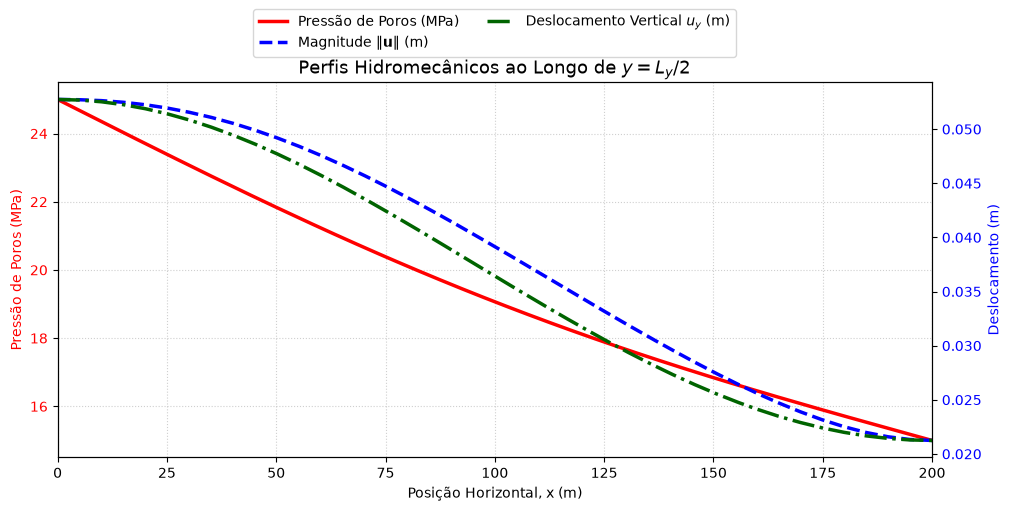

In [95]:
print("Gerando perfil de corte horizontal na metade da altura (y = Ly/2)...")

num_pontos = 200
x_coords = np.linspace(0.0, Lx, num_pontos)
pontos_corte = [(x, Ly / 2.0) for x in x_coords]

# Extração dos perfis
eval_Q = PointEvaluator(domain, pontos_corte)

p_perfil = np.array(eval_Q.evaluate(P_h)) / 1e6
u_perfil = np.array(eval_Q.evaluate(u_mag))
u_y_perfil = np.array(eval_Q.evaluate(u_y))


fig_perfil, ax_p = plt.subplots(figsize=(10, 5), constrained_layout=True)

# Eixo esquerdo: Pressão de poros
linha_p = ax_p.plot(
    x_coords, p_perfil, color="red", linewidth=2.5, label="Pressão de Poros (MPa)"
)
ax_p.set_xlabel("Posição Horizontal, x (m)")
ax_p.set_ylabel("Pressão de Poros (MPa)", color="red")
ax_p.tick_params(axis="y", labelcolor="red")
ax_p.set_xlim(0, Lx)
ax_p.grid(True, which="both", linestyle=":", alpha=0.6)


# Eixo direito: Magnitude do deslocamento
ax_u = ax_p.twinx()
linha_u = ax_u.plot(
    x_coords,
    u_perfil,
    color="blue",
    linestyle="--",
    linewidth=2.5,
    label=r"Magnitude $\|\mathbf{u}\|$ (m)",
)
linha_uy = ax_u.plot(
    x_coords,
    u_y_perfil,
    color="darkgreen",
    linestyle="-.",
    linewidth=2.5,
    label=r"Deslocamento Vertical $u_y$ (m)",
)

ax_u.set_ylabel("Deslocamento (m)", color="blue")
ax_u.tick_params(axis="y", labelcolor="blue")

linhas_totais = linha_p + linha_u + linha_uy
labels_totais = [linha.get_label() for linha in linhas_totais]

ax_p.set_title(r"Perfis Hidromecânicos ao Longo de $y=L_y/2$", fontsize=13)
ax_p.legend(
    linhas_totais,
    labels_totais,
    loc="lower center",
    bbox_to_anchor=(0.5, 1.05),
    ncol=2,
    frameon=True,
)
plt.show()